### This is a quick example of how the dataset can be used in the moving microphone scenario.

At the time of writing, the dataset is still generating.

This folder contains 2 example rooms, and this jupyter notebook that shows some examples of how the dataset can be handled.

Please note: the example-rooms are generated with image source order 5, so very few reflections will be observed.

**A more thorough description of how to handle the dataset, including better examples will follow**

In [37]:
max_length_milliseconds = 100
# if the dataset is in separate files, set FOLDER true
FOLDER = True

# imports: 

import glob
import h5py
import numpy as np
import scipy.signal
from scipy.interpolate import RegularGridInterpolator
import pathlib
import matplotlib.pyplot as plt
from IPython.display import Audio
from scipy.io import wavfile
from IPython.display import display, HTML, Audio
import matplotlib.animation as animation


if FOLDER:
    dataset_dir = r"test-rooms"
    
file_pattern = pathlib.Path(dataset_dir) / "room_*.hdf5"
file_list = sorted(glob.glob(str(file_pattern)))
print(f"Found {len(file_list)} files")


Found 2 files


In [38]:
# helpers: 
def filter_rirs(rirs, fs, cutoff=8000):
    #lp filter: 
    sos = scipy.signal.butter(8, cutoff, btype='low', fs=fs, output='sos')
    M, S, L = rirs.shape
    rirs_out = np.zeros((M, S, L), dtype=np.float32)
    for m in range(M):
        for s in range(S):
            rirs_out[m, s, :] = scipy.signal.sosfilt(sos, rirs[m, s, :])
    return rirs_out

def filter_audio(audio, fs, cutoff=8000):
    sos = scipy.signal.butter(8, cutoff, btype='low', fs=fs, output='sos')
    filtered = scipy.signal.sosfilt(sos, audio)
    return filtered

def reshape_rirs_to_grid(rirs, mic_coords):
    M,S,L=  rirs.shape #(10648, 1, 4800)
    # print(M, S, L)
    
    x = mic_coords[:, 0]
    y = mic_coords[:, 1]
    z = mic_coords[:, 2]

    x_unique = np.unique(x)
    y_unique = np.unique(y)
    z_unique = np.unique(z)

    grid_shape = (len(x_unique), len(y_unique), len(z_unique), S, L)
    rirs_grid = np.full(grid_shape, np.nan)

    for m in range(M):
        xi = np.where(x_unique == x[m])[0][0]
        yi = np.where(y_unique == y[m])[0][0]
        zi = np.where(z_unique == z[m])[0][0]
        rirs_grid[xi, yi, zi, :, :] = rirs[m, :, :]

    return rirs_grid


def flat_to_grid(m, mic_coords):    
    x = mic_coords[:, 0]
    y = mic_coords[:, 1]
    z = mic_coords[:, 2]

    x_unique = np.unique(x)
    y_unique = np.unique(y)
    z_unique = np.unique(z)

    xi = np.where(x_unique == x[m])[0][0]
    yi = np.where(y_unique == y[m])[0][0]
    zi = np.where(z_unique == z[m])[0][0]
    grid_idxs = (xi, yi, zi)
    return grid_idxs

def grid_to_flat(grid_idxs, mic_coords):
    xi, yi, zi = grid_idxs
    x = mic_coords[:, 0]
    y = mic_coords[:, 1]
    z = mic_coords[:, 2]
    x_val = np.unique(x)[xi]
    y_val = np.unique(y)[yi]
    z_val = np.unique(z)[zi]
    listed_rirs = np.where((x == x_val) & (y == y_val) & (z == z_val))[0][0]
    return listed_rirs

# just for displaying:
def norm_audio(x):
    x = np.asarray(x, dtype=np.float32)
    m = np.max(np.abs(x))
    return x / m if m > 0 else x

def display_two_audios_side_by_side(aud_1, aud_2, fs, label_a=None, label_b=None):
    if label_a is None:
        label_a = f"{aud_1}"
    if label_b is None:
        label_b = f"{aud_2}"
    a0 = Audio(norm_audio(aud_1), rate=int(fs))
    a1 = Audio(norm_audio(aud_2), rate=int(fs))
    display(HTML(f"""
    <div style='display:flex; gap:32px; align-items:flex-start; flex-wrap:wrap;'>
      <div>
        <div style='margin-bottom:6px; font-weight:600;'>{label_a}</div>
        {a0._repr_html_()}
      </div>
      <div>
        <div style='margin-bottom:6px; font-weight:600;'>{label_b}</div>
        {a1._repr_html_()}
      </div>
    </div>
    """))

In [40]:
# picking an example room to look at:
example_room = file_list[0]
with h5py.File(example_room, 'r') as f:
    f = f[pathlib.Path(example_room).stem]
    room_info = f['room_information']
    rir_data = f['rir_data']

    room_idx = room_info['room_idx'][()]
    fs = room_info['fs'][()]
    room_corners = room_info['room_corners'][()]
    
    mic_coords = rir_data['mic_coords'][()]
    source_coords = rir_data['source_coords'][()]
    rirs = rir_data['rirs'][()]

max_samples = max_length_milliseconds * fs // 1000
rirs = rirs[:,:,0:max_samples]

rirs = filter_rirs(rirs, fs, cutoff=8000)

In [41]:
#interpolator:
def full_rir_interpolator(rirs, mic_coords, source):
    x_unique = np.unique(mic_coords[:, 0])
    y_unique = np.unique(mic_coords[:, 1])
    z_unique = np.unique(mic_coords[:, 2])
    
    rirs_grid = reshape_rirs_to_grid(rirs, mic_coords) # shape: (22, 22, 22, 1, 4800)
    # select source:
    rirs_grid_4d = rirs_grid[..., source, :]  # shape: (22, 22, 22, 4800)

    # interpolator : takes position and time, returns the full rir at that trajectory_position. 
    interp = RegularGridInterpolator(
        (x_unique, y_unique, z_unique),
        rirs_grid_4d,
        method='linear',
        bounds_error=False,
        fill_value=0.0
    )
    return interp


In [42]:
def mic_array_bounding_box(mic_coords):
    x_min, y_min, z_min = np.min(mic_coords, axis=0)
    x_max, y_max, z_max = np.max(mic_coords, axis=0)
    cube_corners = np.array([
    [x_min, y_min, z_min],
    [x_min, y_min, z_max],
    [x_min, y_max, z_min],
    [x_min, y_max, z_max],
    [x_max, y_min, z_min],
    [x_max, y_min, z_max],
    [x_max, y_max, z_min],
    [x_max, y_max, z_max],
    ])

    edges = [
        (0,1), (0,2), (0,4),
        (1,3), (1,5),
        (2,3), (2,6),
        (3,7),
        (4,5), (4,6),
        (5,7),
        (6,7)
    ]
    return edges, cube_corners


# definition of trajectories:

def create_trajectory(mic_coords, traj_length_seconds, traj_sampling_rate, trajectory_type="diagonal"):
    edges, cube_corners = mic_array_bounding_box(mic_coords)
    x_min, y_min, z_min = np.min(mic_coords, axis=0)
    x_max, y_max, z_max = np.max(mic_coords, axis=0)
    traj_times = np.linspace(0, traj_length_seconds, int(traj_length_seconds * traj_sampling_rate))

    traj_positions = np.zeros((len(traj_times), 3))
    if trajectory_type == "diagonal":
        # linear trajectory from 1 corner to the other
        traj_positions[:, 0] = np.linspace(mic_coords[0, 0], mic_coords[-1, 0], len(traj_times))
        traj_positions[:, 1] = np.linspace(mic_coords[0, 1], mic_coords[-1, 1], len(traj_times))
        traj_positions[:, 2] = np.linspace(mic_coords[0, 2], mic_coords[-1, 2], len(traj_times))
        
    elif trajectory_type == "circular":
        center = np.mean(mic_coords, axis=0)
        max_mic_coords = np.max(mic_coords, axis=0)
        
        radius = np.linalg.norm(max_mic_coords - center) * 0.55
        traj_positions[:, 0] = center[0] + radius * np.cos(2 * np.pi * traj_times / traj_length_seconds)
        traj_positions[:, 1] = center[1] + radius * np.sin(2 * np.pi * traj_times / traj_length_seconds)
        traj_positions[:, 2] = center[2]
        
    elif trajectory_type == "curved_movement":
        center = np.mean(mic_coords, axis=0)
        box_size = np.array([x_max - x_min, y_max - y_min, z_max - z_min])
        max_radius = np.min(box_size) / 2 * 0.9  # 70% of smallest dimension
        
        traj_positions[:, 0] = center[0] + max_radius * np.cos(2 * np.pi * traj_times / traj_length_seconds)
        traj_positions[:, 1] = center[1] + max_radius * np.sin(4 * np.pi * traj_times / traj_length_seconds)  
        traj_positions[:, 2] = center[2] + max_radius * 0.5 * np.sin(2 * np.pi * traj_times / traj_length_seconds)
    
    traj_samples = (traj_times * fs).astype(int)
    
    return traj_positions, traj_times, traj_samples

In [43]:
# beginning of main code:

source = 4

traj_length_seconds = 1
traj_sampling_rate = 200
traj_positions, traj_times, traj_samples = create_trajectory(mic_coords, traj_length_seconds, traj_sampling_rate, trajectory_type="curved_movement")

interp = full_rir_interpolator(rirs, mic_coords, source)
rirs_at_trajectory = []
for i in range(len(traj_positions)):
    pos = traj_positions[i]
    full_rir = interp(pos)
    rirs_at_trajectory.append(full_rir)
    
print("if the following are non-zero, then you are probably good to go with the interpolation:")
print("rir at position 0:", rirs_at_trajectory[0][0][:10]) 
print("coordinates at position 0:", traj_positions[0])  

if the following are non-zero, then you are probably good to go with the interpolation:
rir at position 0: [-6.32475631e-06 -7.37683551e-05 -4.05619052e-04 -1.40140549e-03
 -3.42190461e-03 -6.29975063e-03 -9.12226699e-03 -1.07516793e-02
 -1.07350201e-02 -9.69450834e-03]
coordinates at position 0: [0.99551783 2.02018759 2.35157107]


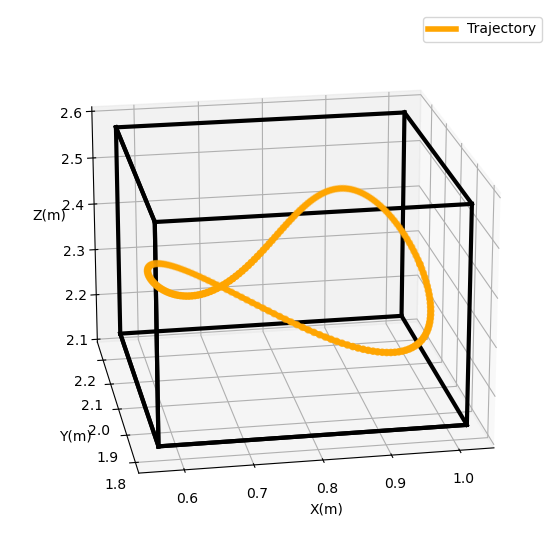

In [44]:
# plotting the trajectory and box bounding the mic array:

x_min, y_min, z_min = np.min(mic_coords, axis=0)
x_max, y_max, z_max = np.max(mic_coords, axis=0)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
edges, cube_corners = mic_array_bounding_box(mic_coords)

for edge in edges:
    p1, p2 = cube_corners[edge[0]], cube_corners[edge[1]]
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color='black', linewidth=3)

ax.plot(traj_positions[:, 0], traj_positions[:, 1], traj_positions[:, 2], color='orange', linewidth=4, label='Trajectory')
ax.scatter3D(traj_positions[:, 0], traj_positions[:, 1], traj_positions[:, 2], color='orange', s=20)


for front_edges in edges[:4]:  # only plot the front edges of the cube for better visualization
     p1, p2 = cube_corners[front_edges[0]], cube_corners[front_edges[1]]
     ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color='black', linewidth=3)

ax.set_xlabel('X(m)')
ax.set_ylabel('Y(m)')
ax.set_zlabel('Z(m)')
ax.view_init(elev=20, azim=260)
ax.legend()
plt.show()

In [45]:
# loading a clip from the ears dataset for conlvolution
# https://sp-uhh.github.io/ears_dataset/

# @inproceedings{richter2024ears,
#     title={{EARS}: An Anechoic Fullband Speech Dataset Benchmarked for Speech Enhancement and Dereverberation},
#     author={Julius Richter and Yi-Chiao Wu and Steven Krenn and Simon Welker and Bunlong Lay and Shinjii Watanabe and Alexander Richard and Timo Gerkmann},
#     booktitle={ISCA Interspeech},
#     pages={4873--4877},
#     year={2024}
# }

audio_sr, audio_clip = wavfile.read(r'p008_emo_contentment_sentences.wav')
offset = int(0.6*audio_sr)
audio_clip = audio_clip[offset:offset+audio_sr*traj_length_seconds*2]  # trim to trajectory length for example

if audio_sr != fs:
    print(f"resampling to fs: {fs}.")
    number_of_samples = round(len(audio_clip) * float(fs) / audio_sr)
    audio_clip = scipy.signal.resample(audio_clip, number_of_samples)
    print(f"new audio shape: {audio_clip.shape}")
    
    
audio_clip_filtered = filter_audio(audio_clip, audio_sr, cutoff=8000)


rir_first_conv = scipy.signal.convolve(audio_clip, rirs_at_trajectory[0][0][:], mode='full')
rir_last_conv = scipy.signal.convolve(audio_clip, rirs_at_trajectory[-1][0][:], mode='full')

display_two_audios_side_by_side(rir_first_conv, rir_last_conv, fs, label_a="RIR at start of trajectory", label_b="RIR at end of trajectory")

In [46]:
# convolve all rirs with audio:
convolved_audios = []
for i in range(len(rirs_at_trajectory)):
    convolved_audio = scipy.signal.convolve(audio_clip, rirs_at_trajectory[i][0][:], mode='full')
    convolved_audios.append(convolved_audio)
print(f"Convolved {len(convolved_audios)} audios along the trajectory.")

# convolve all rirs with audio:
convolved_audios_filtered = []
for i in range(len(rirs_at_trajectory)):
    convolved_audio = scipy.signal.convolve(audio_clip_filtered, rirs_at_trajectory[i][0][:], mode='full')
    convolved_audios_filtered.append(convolved_audio)
print(f"Convolved {len(convolved_audios_filtered)} audios along the trajectory.")

Convolved 200 audios along the trajectory.
Convolved 200 audios along the trajectory.


In [47]:
def hann_crossfade(traj_samples, convolved_audios):
    convolved_audios = np.asarray(convolved_audios)
    num_convolved_audios, total_length = convolved_audios.shape

    weights = np.zeros((num_convolved_audios, total_length), dtype=float)

    weights[0, :traj_samples[0]] = 1.0
    # crossfade between each pair of consecutive segments:
    for k in range(num_convolved_audios - 1):
        c0 = traj_samples[k]
        c1 = traj_samples[k + 1]

        fade_len = c1 - c0
        x = np.linspace(0, np.pi, fade_len, endpoint=False)
        win = 0.5 * (1 - np.cos(x)) 
        
        weights[k, c0:c1] += 1 - win
        weights[k+1, c0:c1] += win

    weights[-1, traj_samples[-1]:] = 1.0

    gain = np.sum(weights, axis=0, keepdims=True)
    gain[gain == 0] = 1.0
    weights /= gain

    moving_signal = np.sum(weights * convolved_audios, axis=0)
    return moving_signal, weights


moving_signal, weights_pairwise = hann_crossfade(traj_samples, convolved_audios)
moving_signal_filtered, weights_pairwise_filtered = hann_crossfade(traj_samples, convolved_audios_filtered)

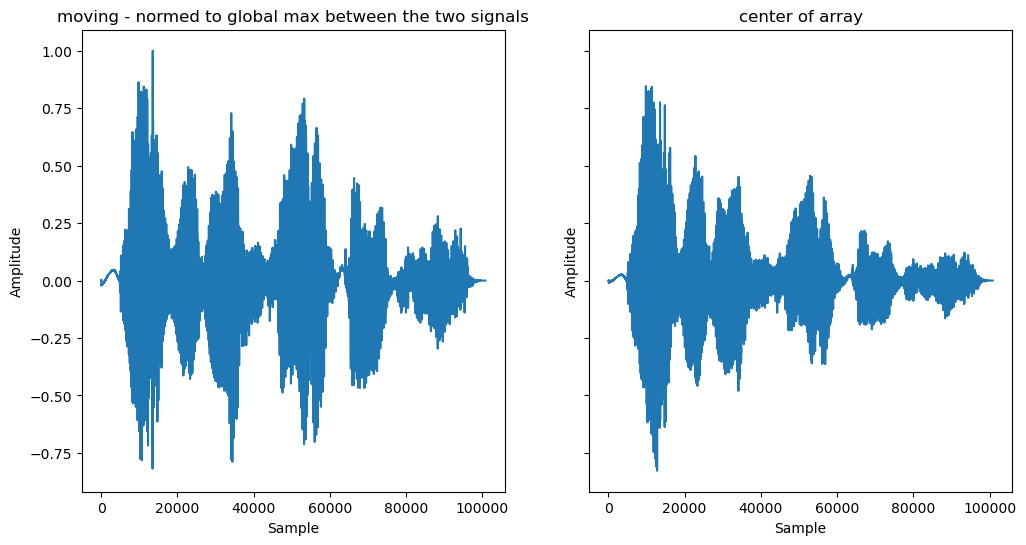

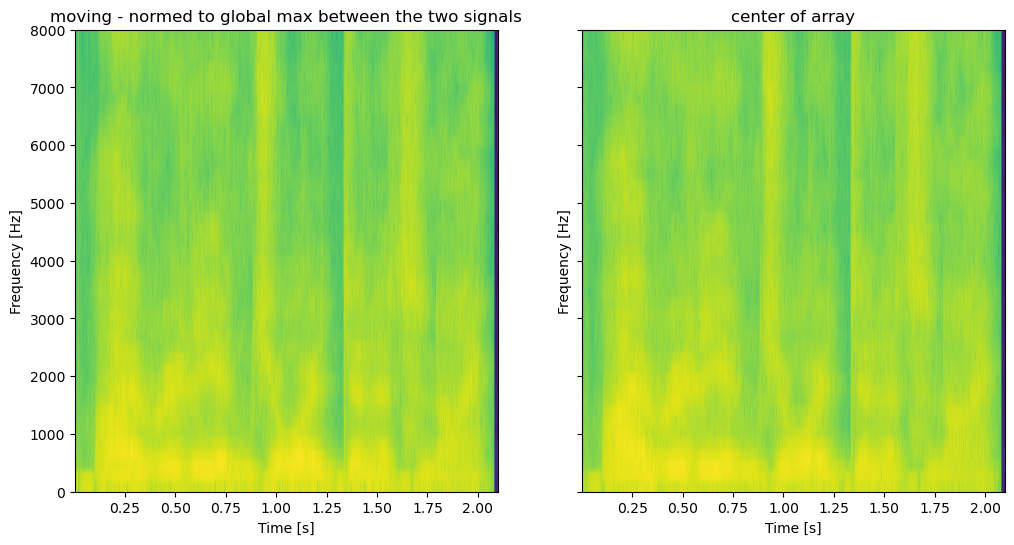

In [48]:
# non-filtered audio clip: 

display_two_audios_side_by_side(moving_signal, convolved_audios[len(convolved_audios)//2], fs, label_a="moving signal", label_b="middle of the trajectory (steady mic)")

# wavfile.write("moving_signal.wav", fs, norm_audio(moving_signal).astype(np.float32))
# wavfile.write("steady_signal.wav", fs, norm_audio(convolved_audios[len(convolved_audios)//2]).astype(np.float32))

global_norm = max(np.max(np.abs(moving_signal)), np.max(np.abs(convolved_audios[len(convolved_audios)//2])))

normed_moving_signal = moving_signal / global_norm
normed_steady_signal = convolved_audios[len(convolved_audios)//2] / global_norm


fig, ax = plt.subplots(1,2, figsize=(12, 6), sharey=True)
ax[0].plot(normed_moving_signal)
ax[0].set_title("moving - normed to global max between the two signals")
ax[0].set_xlabel("Sample")
ax[0].set_ylabel("Amplitude")

ax[1].plot(normed_steady_signal)
ax[1].set_title("center of array")
ax[1].set_xlabel("Sample")
ax[1].set_ylabel("Amplitude")
plt.show()

fig, ax = plt.subplots(1,2, figsize=(12, 6), sharey=True)
ax[0].specgram(normed_moving_signal, Fs=fs)
ax[0].set_title("moving - normed to global max between the two signals")
ax[0].set_xlabel("Time [s]")
ax[0].set_ylabel("Frequency [Hz]")
ax[0].set_ylim(0, 8000)
# ax[0].colorbar(label="Intensity [dB]")

ax[1].specgram(normed_steady_signal, Fs=fs)
ax[1].set_title("center of array")
ax[1].set_xlabel("Time [s]")
ax[1].set_ylabel("Frequency [Hz]")
ax[1].set_ylim(0, 8000)
# ax[1].colorbar(label="Intensity [dB]")
plt.show()

